In [17]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("house-prices.csv")
df.head()

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East


In [7]:
print(df.info())
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Home          128 non-null    int64 
 1   Price         128 non-null    int64 
 2   SqFt          128 non-null    int64 
 3   Bedrooms      128 non-null    int64 
 4   Bathrooms     128 non-null    int64 
 5   Offers        128 non-null    int64 
 6   Brick         128 non-null    object
 7   Neighborhood  128 non-null    object
dtypes: int64(6), object(2)
memory usage: 8.1+ KB
None


(128, 8)

In [4]:
df.describe()

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers
count,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000
mean,64.500000,130427.343750,2000.937500,3.023438,2.445312,2.578125
std,37.094474,26868.770371,211.572431,0.725951,0.514492,1.069324
min,1.000000,69100.000000,1450.000000,2.000000,2.000000,1.000000
25%,32.750000,111325.000000,1880.000000,3.000000,2.000000,2.000000
50%,64.500000,125950.000000,2000.000000,3.000000,2.000000,3.000000
75%,96.250000,148250.000000,2140.000000,3.000000,3.000000,3.000000
max,128.000000,211200.000000,2590.000000,5.000000,4.000000,6.000000


In [5]:
df.isnull().sum()

Home            0
Price           0
SqFt            0
Bedrooms        0
Bathrooms       0
Offers          0
Brick           0
Neighborhood    0
dtype: int64

In [9]:
df = pd.get_dummies(df, columns=["Brick", "Neighborhood"], drop_first=True)

The independent variable is selected as the input feature, while the house price is considered the target variable. In simple linear regression, only one feature is used to predict the continuous output value.
Scenario 1: SqFt is used to predict Price.


MAE : 15945.548715686047
MSE : 415765840.64103884
RMSE: 20390.33694280305
R² : 0.2945934454247471


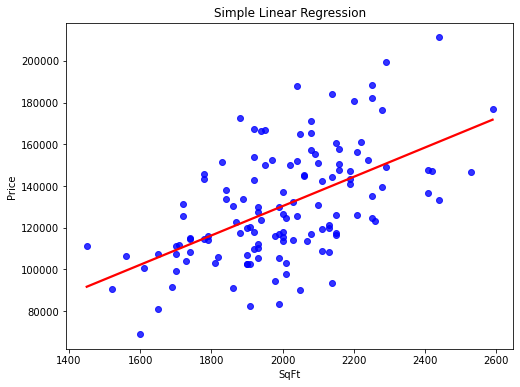

In [21]:
X = df[['SqFt']]
y = df['Price']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² :", r2_score(y_test, y_pred))

# Regression Graph
plt.figure(figsize=(8,6))

sns.regplot(
    x="SqFt",
    y="Price",
    data=df,
    ci=None,
    scatter_kws={"color":"blue"},
    line_kws={"color":"red"}
)

plt.title("Simple Linear Regression")
plt.show()

This indicates that SqFt has a relationship with price, but other factors also significantly influence house prices. The model shows a moderate relationship between house size and price. However, using only SqFt is not sufficient for highly accurate predictions because house prices depend on multiple factors such as bedrooms, bathrooms, location, and construction type.

The upward trend of the line indicates that houses with larger square footage generally have higher prices.

The independent variable is selected as the input feature, while the house price is considered the target variable. In simple linear regression, only one feature is used to predict the continuous output value.
Scenario 2: Bedrooms is used to predict Price.

MAE : 14447.435897435897
MSE : 356973461.53846145
RMSE : 18893.741332474663
R² Score : 0.3943431735748225


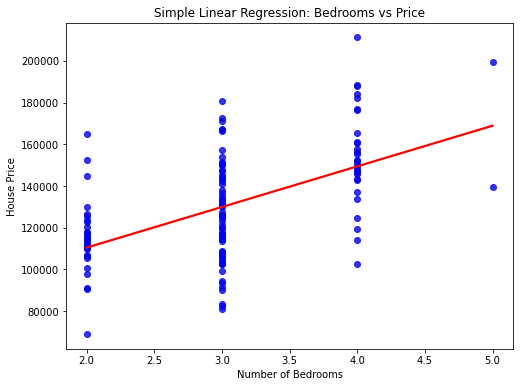

In [22]:
X = df[['Bedrooms']]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score :", r2_score(y_test, y_pred))

plt.figure(figsize=(8,6))

sns.regplot(
    x="Bedrooms",
    y="Price",
    data=df,
    ci=None,
    scatter_kws={"color":"blue"},
    line_kws={"color":"red"}
)

plt.title("Simple Linear Regression: Bedrooms vs Price")

plt.xlabel("Number of Bedrooms")

plt.ylabel("House Price")

plt.show()


This indicates that bedrooms provide some predictive information, but they are not enough to accurately determine house prices. The model identifies a relationship between the number of bedrooms and house prices. However, bedroom count alone is a limited predictor because houses with the same number of bedrooms can have different prices due to factors such as size, location, bathrooms, and additional facilities.

The positive slope indicates that houses with more bedrooms generally tend to have higher prices.

In [24]:
X = df.drop(["Home", "Price"], axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [25]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\n========== Evaluation for multiple ==========")

print("MAE :", mae)

print("MSE :", mse)

print("RMSE:", rmse)

print("R² Score:", r2)


========== Evaluation for multiple ==========
MAE : 8901.290743964862
MSE : 114170418.45453855
RMSE: 10685.055847048183
R² Score: 0.8062934622232132


The multiple linear regression model performs better than the simple linear regression models because it considers multiple factors affecting house prices. Features such as square footage, number of bedrooms, bathrooms, offers, brick type, and neighborhood collectively provide more information for predicting prices.

The high R² score indicates that the model generalizes well and captures most of the patterns present in the dataset. With an R² score of 0.8063, the model explains more than 80% of the variation in prices, demonstrating better predictive ability and improved generalization.

In [12]:
train_r2 = model.score(X_train, y_train)

test_r2 = model.score(X_test, y_test)

print("\nTraining R² :", train_r2)

print("Testing R² :", test_r2)

if abs(train_r2 - test_r2) < 0.05:
    print("\nThe model is generalized.")
else:
    print("\nThe model shows signs of overfitting.")


Training R² : 0.8791156880121863
Testing R² : 0.8062934622232132

The model shows signs of overfitting.


Training R² : 0.8791156880121863
Testing R² : 0.8062934622232132
Difference = 0.0728 (7.28%)
Model shows slight overfitting

Cross-Validation is the strongest overfitting solution candidate because:

It uses different subsets of the data for training and validation.
It provides a more reliable estimate of how the model performs on unseen data.
It helps detect whether the model's performance is consistent across different data splits.

In [15]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross Validation R² Scores:")
print(cv_scores)

print("\nAverage Cross Validation R²:", cv_scores.mean())

Cross Validation R² Scores:
[0.89544592 0.83377928 0.63420523 0.84565176 0.91808335]

Average Cross Validation R²: 0.8254331103707889


In [13]:
result = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

print("\nActual vs Predicted")

print(result.head(10))


Actual vs Predicted
     Actual Price  Predicted Price
55         125700    116001.901206
40         106600     98256.155058
19         167200    160639.972377
31         112300    129960.648097
98         145500    153771.273335
56         140900    139093.557576
69         165600    148513.071405
104         82300     97107.455760
81         184300    177414.958341
26         137000    136790.110990


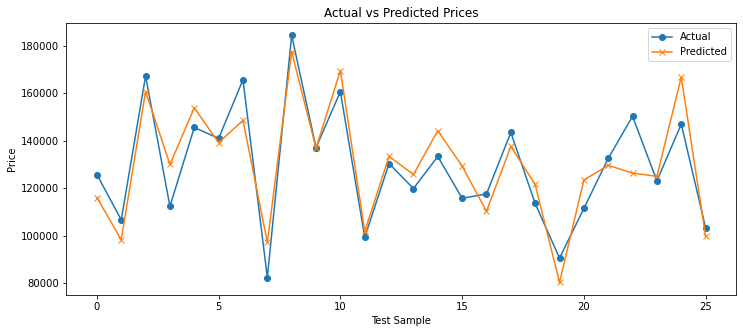

In [18]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
}).reset_index(drop=True)

plt.figure(figsize=(12,5))

plt.plot(comparison["Actual"], label="Actual", marker='o')

plt.plot(comparison["Predicted"], label="Predicted", marker='x')

plt.title("Actual vs Predicted Prices")

plt.xlabel("Test Sample")

plt.ylabel("Price")

plt.legend()

plt.show()

In [14]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nFeature Importance")

print(coef.sort_values(by="Coefficient", key=abs, ascending=False))


Feature Importance
              Feature   Coefficient
0                SqFt  12163.184747
6   Neighborhood_West  10159.125316
3              Offers  -9531.331691
4           Brick_Yes   7646.503514
2           Bathrooms   3613.944676
1            Bedrooms   2676.640111
5  Neighborhood_North    710.367272
